In [18]:
#importamos librerias 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [31]:
dfB=pd.read_csv('Bozeman_limpio_final.csv')
dfB.head()

,Unnamed: 0.1,Unnamed: 0,last_scraped,source,name,description,host_name,host_since,host_location,host_about,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,reviews_per_month
0,0,0,09/11/2024,city scrape,Unique neighborhood cottage,"Not for everyone, but loved by many'<br />' Th...",Stacie,29/05/2012,"Bozeman, MT",I love my home and love sharing it.,...,1.0,4.95,4.95,4.97,4.99,4.98,4.98,4.89,1.0,1.72
1,1,1,09/11/2024,city scrape,Downtown Bozeman Vacation Rental,Just four easy blocks from historic downtown B...,Brian,08/11/2013,"Bozeman, MT",I'm a born and raised Montanan. I've done some...,...,5.0,4.97,4.98,4.95,4.97,4.99,4.93,4.94,2.0,3.92
2,2,2,09/11/2024,city scrape,Northside Hideaway,"Free, fast Wi-Fi for remote learning/working n...",Paul,17/08/2013,"Bozeman, MT",I started Bozeman Cottage Vacation Rentals in ...,...,1.0,4.76,4.89,4.82,4.95,4.97,4.97,4.70,3.0,0.30
3,3,3,09/11/2024,city scrape,2 Blocks 2 Main,This space is designed for 1-2 people that wan...,Irene,31/07/2013,"Bozeman, MT",I have lived in or near Bozeman all of my life...,...,0.0,4.96,5.00,5.00,5.00,4.98,5.00,4.73,2.0,0.47
4,4,4,09/11/2024,city scrape,Modern Home Near Campus & Downtown,"Great house on the south side of town, near ca...",Kris And Alex,20/08/2013,"Livingston, MT",We have been traveling with Airbnb for the pas...,...,2.0,4.77,4.87,4.90,4.91,4.83,4.89,4.73,1.0,2.46


In [33]:
#dfB=dfB.drop('Unnamed: 0',axis=1)
dfB=dfB.drop( 'Unnamed: 0.1',axis=1)
dfB.head()
dfB.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 49 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0       last_scraped                567 non-null    object 
 1   source                          567 non-null    object 
 2   name                            567 non-null    object 
 3   description                     567 non-null    object 
 4   host_name                       567 non-null    object 
 5   host_since                      567 non-null    object 
 6   host_location                   567 non-null    object 
 7   host_about                      567 non-null    object 
 8   host_response_time              567 non-null    object 
 9   host_response_rate              567 non-null    object 
 10  host_acceptance_rate            567 non-null    float64
 11  host_is_superhost               567 non-null    object 
 12  host_verifications              567 

In [34]:
dfB.drop(dfB.columns[[0,1,2,3,4,5,6,7,8,9,12,13,15,18,20,21,22,24,29,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,47]], axis=1, inplace=True)


In [23]:
dfB.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   host_acceptance_rate       567 non-null    float64
 1   host_is_superhost          567 non-null    object 
 2   host_identity_verified     567 non-null    object 
 3   property_type              567 non-null    object 
 4   room_type                  567 non-null    object 
 5   price                      567 non-null    float64
 6   instant_bookable           567 non-null    object 
 7   host_total_listings_count  567 non-null    float64
 8   accommodates               567 non-null    float64
 9   bathrooms                  567 non-null    float64
 10  bedrooms                   567 non-null    int64  
 11  review_scores_cleanliness  567 non-null    float64
 12  review_scores_value        567 non-null    float64
 13  reviews_per_month          567 non-null    float64

In [35]:
dfB["host_is_superhost"] = dfB["host_is_superhost"].map({"t": 1, "f": 0})


In [11]:
dfB.info()
dfB.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   host_acceptance_rate       567 non-null    float64
 1   host_is_superhost          0 non-null      float64
 2   host_identity_verified     567 non-null    object 
 3   property_type              567 non-null    object 
 4   room_type                  567 non-null    object 
 5   price                      567 non-null    float64
 6   instant_bookable           567 non-null    object 
 7   host_total_listings_count  567 non-null    float64
 8   accommodates               567 non-null    float64
 9   bathrooms                  567 non-null    float64
 10  bedrooms                   567 non-null    int64  
 11  review_scores_cleanliness  567 non-null    float64
 12  review_scores_value        567 non-null    float64
 13  reviews_per_month          567 non-null    float64

,host_acceptance_rate,host_is_superhost,host_identity_verified,property_type,room_type,price,instant_bookable,host_total_listings_count,accommodates,bathrooms,bedrooms,review_scores_cleanliness,review_scores_value,reviews_per_month
0,0.92,NaN,t,Entire home,Entire home/apt,150.0,f,1.0,2.0,2.0,2,4.97,4.89,1.72
1,1.00,NaN,t,Entire guesthouse,Entire home/apt,135.0,f,2.0,2.0,1.0,1,4.95,4.94,3.92
2,0.99,NaN,t,Entire home,Entire home/apt,167.0,f,38.0,4.0,1.5,1,4.82,4.70,0.30
3,0.92,NaN,f,Entire rental unit,Entire home/apt,175.0,t,2.0,2.0,1.0,1,5.00,4.73,0.47
4,1.00,NaN,t,Entire home,Entire home/apt,255.0,f,2.0,6.0,2.0,3,4.90,4.73,2.46


In [36]:
dfB = pd.get_dummies(dfB, columns=["room_type"], drop_first=False)


In [37]:
print(dfB.filter(like="room_type").columns)


Index(['room_type_Entire home/apt', 'room_type_Hotel room',
       'room_type_Private room', 'room_type_Shared room'],
      dtype='object')


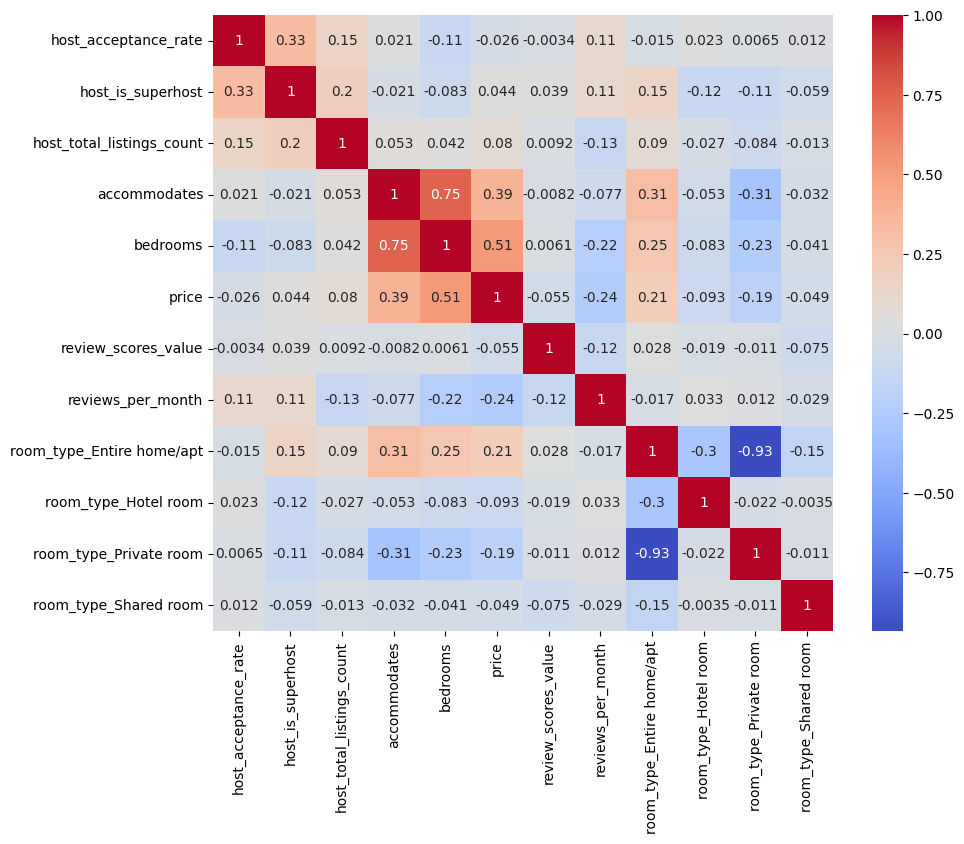

NameError: name 'LinearRegression' is not defined

In [38]:
var_cuant = [
    "host_acceptance_rate",
    "host_is_superhost",
    "host_total_listings_count",
    "accommodates",
    "bedrooms",
    "price",
    "review_scores_value",
    "reviews_per_month",
    # Incluye aquí las columnas dummies creadas:
    "room_type_Entire home/apt", 
    "room_type_Hotel room",
    "room_type_Private room", 
    "room_type_Shared room"
]

# 3) Matriz de correlación
corr_matrix = dfB[var_cuant].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

# 4) Crear un modelo de regresión lineal para CADA variable en var_cuant como Y
resultados = []

for var_objetivo in var_cuant:
    # X = todas las columnas salvo la que se está prediciendo
    X = dfB[var_cuant].drop(columns=[var_objetivo])
    y = dfB[var_objetivo]

    # Ajuste del modelo
    model = LinearRegression()
    model.fit(X, y)

    # Almacenar métricas y coeficientes
    r2 = model.score(X, y)
    coeficientes = model.coef_
    intercepto = model.intercept_

    resultados.append({
        'Variable_Predicha': var_objetivo,
        'R^2': r2,
        'Intercepto': intercepto,
        'Coeficientes': coeficientes,
        'Columnas_X': X.columns.tolist()
    })

# 5) Mostrar resultados en un DataFrame
df_resultados = pd.DataFrame(resultados)
df_resultados